# 1. Load the data & inspect

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from dotenv import load_dotenv
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

load_dotenv()
DATA_DIR = Path(os.getenv("MAIN_PATH"))

In [6]:
train = pd.read_csv(DATA_DIR / "train-test.csv")
validation = pd.read_csv(DATA_DIR / "validation.csv")
template = pd.read_csv(DATA_DIR / "validation-predictions-template.csv")
december = pd.read_csv(DATA_DIR / "december-chart-inputs.csv")
for frame in [train, validation, december]:
    frame["date"] = pd.to_datetime(frame["date"])

train.shape, validation.shape, december.shape

((48000, 14), (12000, 13), (31, 7))

In [3]:
train.isna().sum().sort_values(ascending=False), train.describe(include="all").T

(market_index    374
 weight          300
 delivery          0
 pickup_lat        0
 load_id           0
 pickup            0
 delivery_lat      0
 pickup_lon        0
 distance          0
 delivery_lon      0
 equipment         0
 date              0
 quote_signal      0
 posted_rate       0
 dtype: int64,
                 count unique            top   freq  \
 load_id         48000  48000      TR-000001      1   
 pickup          48000     64  Oklahoma City   1242   
 delivery        48000     64      Lexington   1197   
 pickup_lat    48000.0    NaN            NaN    NaN   
 pickup_lon    48000.0    NaN            NaN    NaN   
 delivery_lat  48000.0    NaN            NaN    NaN   
 delivery_lon  48000.0    NaN            NaN    NaN   
 distance      48000.0    NaN            NaN    NaN   
 equipment       48000      3        Dry Van  27202   
 weight        47700.0    NaN            NaN    NaN   
 date            48000    NaN            NaN    NaN   
 market_index  47626.0    NaN  

## 2. Explore rate per mile

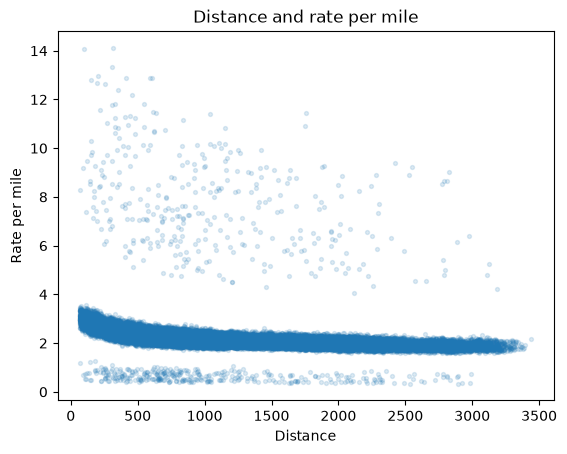

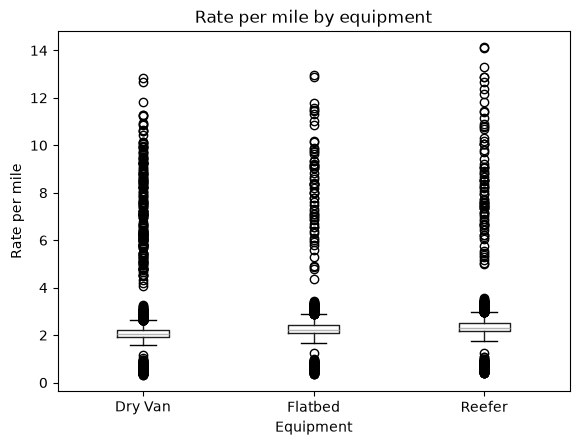

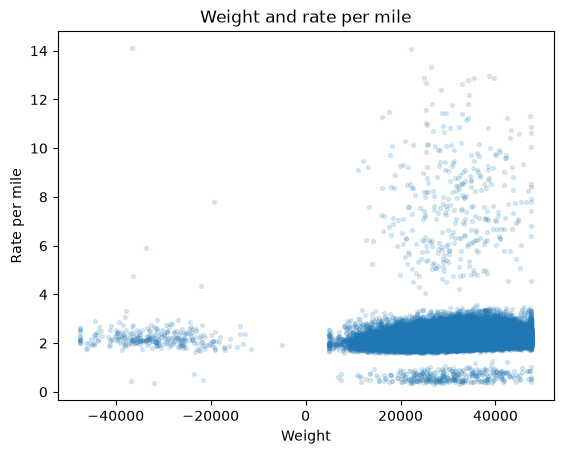

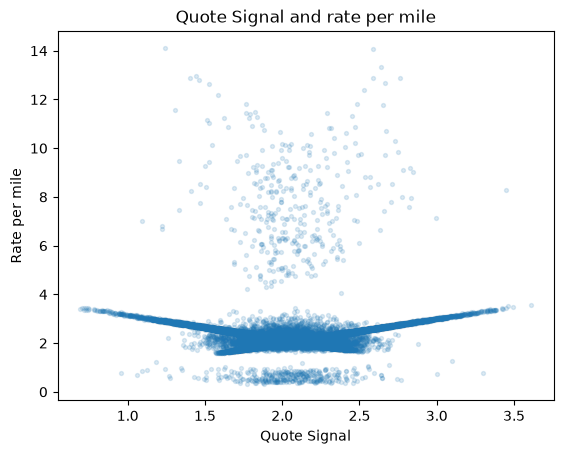

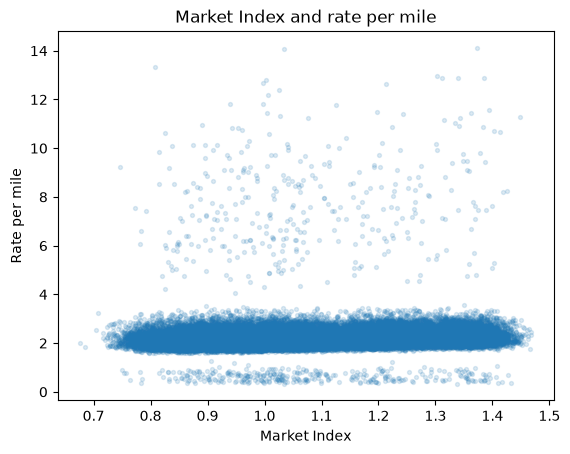

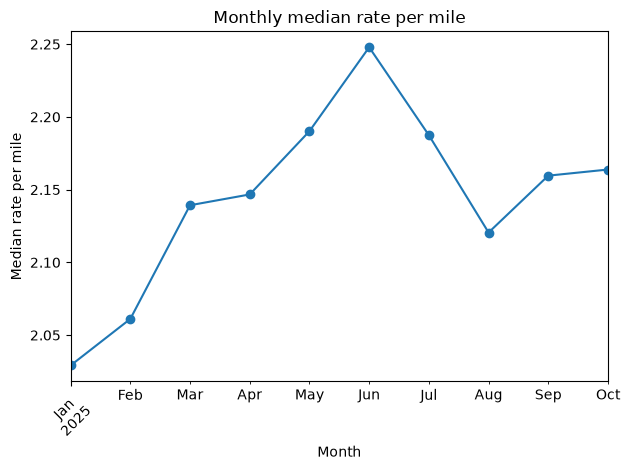

In [7]:
train = train.loc[train["distance"] > 0].copy()
train["rpm"] = train["posted_rate"] / train["distance"]

plt.scatter(train["distance"], train["rpm"], s=8, alpha=0.15)
plt.xlabel("Distance")
plt.ylabel("Rate per mile")
plt.title("Distance and rate per mile")
plt.show()

train.boxplot(column="rpm", by="equipment", grid=False)
plt.xlabel("Equipment")
plt.ylabel("Rate per mile")
plt.title("Rate per mile by equipment")
plt.suptitle("")
plt.show()

for column in ["weight", "quote_signal", "market_index"]:
    plt.scatter(train[column], train["rpm"], s=8, alpha=0.15)
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Rate per mile")
    plt.title(f"{column.replace('_', ' ').title()} and rate per mile")
    plt.show()

train.groupby(train["date"].dt.to_period("M"))["rpm"].median().plot(marker="o")
plt.xlabel("Month")
plt.ylabel("Median rate per mile")
plt.title("Monthly median rate per mile")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Prepare features

In [8]:
def add_features(frame):
    frame = frame.copy()
    frame["date"] = pd.to_datetime(frame["date"])
    frame["day_of_week"] = frame["date"].dt.dayofweek
    frame["log_distance"] = np.log1p(frame["distance"].clip(lower=0))

    if "weight" in frame.columns:
        frame["weight"] = frame["weight"].abs()
        frame["weight_capped"] = frame["weight"].eq(47500).astype(int)

    if "quote_signal" in frame.columns:
        frame["quote_signal_sq"] = frame["quote_signal"] ** 2

    return frame


train = add_features(train)
validation = add_features(validation)

train["rpm"] = train["posted_rate"] / train["distance"].replace(0, np.nan)
train = train.loc[
    train["rpm"].notna() & np.isfinite(train["rpm"])
].copy()

numeric_features = [
    "pickup_lat", "pickup_lon",
    "delivery_lat", "delivery_lon",
    "distance", "log_distance",
    "weight", "weight_capped",
    "market_index",
    "quote_signal", "quote_signal_sq",
    "day_of_week"
]

categorical_features = ["pickup", "delivery", "equipment"]

feature_columns = numeric_features + categorical_features

In [ ]:
def clean_mask(reference, rows):
    bins = np.unique(np.quantile(reference["distance"], np.linspace(0, 1, 21)))
    reference_bins = pd.cut(reference["distance"], bins=bins, include_lowest=True)
    median_rpm = reference.groupby(reference_bins, observed=True)["rpm"].median()
    row_bins = pd.cut(rows["distance"], bins=bins, include_lowest=True)
    expected_rpm = row_bins.map(median_rpm)
    expected_rpm = pd.to_numeric(expected_rpm, errors="coerce").fillna(
        reference["rpm"].median()
    )
    return (rows["rpm"].to_numpy() >= 0.55 * expected_rpm.to_numpy()) & (
        rows["rpm"].to_numpy() <= 1.60 * expected_rpm.to_numpy()
    )

def rate_metrics(y_true, y_pred, rows=None, reference=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    valid = (y_true > 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]
    result = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE (%)": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "R2": r2_score(y_true, y_pred),
    }
    if rows is not None and reference is not None:
        clean = clean_mask(reference, rows)
        clean = np.asarray(clean)[valid]
        result["Clean MAE"] = mean_absolute_error(y_true[clean], y_pred[clean])
        result["Clean MAPE (%)"] = (np.mean(np.abs((y_true[clean] - y_pred[clean]) / y_true[clean])) * 100)

    return result

dev = train.loc[train["date"] < "2025-09-01"].copy()

holdout = train.loc[(train["date"] >= "2025-09-01") &(train["date"] < "2025-11-01")].copy()

len(dev), len(holdout)

(38477, 9523)

## 4. Model Validation

In [ ]:
baseline_num = [
    "log_distance",
    "weight",
    "weight_capped",
    "quote_signal",
    "quote_signal_sq",
    "day_of_week"
]

baseline_cat = ["equipment", "pickup", "delivery"]

baseline_prep = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]),
        baseline_num
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        baseline_cat
    )
])

baseline = Pipeline([
    ("prep", baseline_prep),
    ("model", Ridge(alpha=10))
])

baseline.fit(dev[baseline_num + baseline_cat], np.log1p(dev["posted_rate"]))

baseline_pred = np.expm1(
    baseline.predict(
        holdout[baseline_num + baseline_cat]
    )
)

baseline_metrics = rate_metrics(
    holdout["posted_rate"],
    baseline_pred,
    holdout,
    dev
)

baseline_metrics

{'MAE': 106.62990518479836,
 'RMSE': 633.3800423150221,
 'MAPE (%)': np.float64(4.606101019107119),
 'R2': 0.8277378462046386,
 'Clean MAE': 50.693532650389365,
 'Clean MAPE (%)': np.float64(2.0938294572007887)}

# 5. Gradient Boosting

In [13]:
def make_boosting_model(features, categories):
    prep = ColumnTransformer([
        (
            "num",
            SimpleImputer(strategy="median"),
            features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categories
        )
    ])

    return Pipeline([
        ("prep", prep),
        (
            "model",
            HistGradientBoostingRegressor(
                loss="absolute_error",
                max_iter=250,
                learning_rate=0.06,
                max_leaf_nodes=15,
                l2_regularization=1.0,
                random_state=42
            )
        )
    ])


def evaluate_boosting(
    use_market=True,
    fit_rows=None,
    test_rows=None
):
    fit_rows = dev if fit_rows is None else fit_rows
    test_rows = holdout if test_rows is None else test_rows

    nums = numeric_features.copy()

    if not use_market:
        nums = [
            c for c in nums
            if c != "market_index"
        ]

    model = make_boosting_model(
        nums,
        categorical_features
    )

    model.fit(
        fit_rows[nums + categorical_features],
        fit_rows["rpm"]
    )

    pred = (
        model.predict(
            test_rows[nums + categorical_features]
        )
        * test_rows["distance"].to_numpy()
    )

    metrics = rate_metrics(
        test_rows["posted_rate"],
        pred,
        test_rows,
        fit_rows
    )

    return model, metrics


boost_market, market_metrics = evaluate_boosting(True)
boost_no_market, no_market_metrics = evaluate_boosting(False)

pd.DataFrame([
    {
        "Model": "Boosting with market_index",
        **market_metrics
    },
    {
        "Model": "Boosting without market_index",
        **no_market_metrics
    }
]).set_index("Model")

,MAE,RMSE,MAPE (%),R2,Clean MAE,Clean MAPE (%)
Model,,,,,,
Boosting with market_index,134.705412,641.674307,5.540858,0.823197,79.203354,3.105053
Boosting without market_index,88.311714,629.179498,3.804325,0.830015,32.188486,1.276093


## 6. Final Predictions

In [15]:
def evaluate_ridge(fit_rows, test_rows):
    ridge = Pipeline([
        ("prep", baseline_prep),
        ("model", Ridge(alpha=10))
    ])

    ridge.fit(
        fit_rows[baseline_num + baseline_cat],
        np.log1p(fit_rows["posted_rate"])
    )

    pred = np.expm1(
        ridge.predict(
            test_rows[baseline_num + baseline_cat]
        )
    )

    return rate_metrics(
        test_rows["posted_rate"],
        pred,
        test_rows,
        fit_rows
    )


model_comparison = []

for month in range(7, 11):
    start = pd.Timestamp(2025, month, 1)
    end = start + pd.offsets.MonthBegin(1)

    fit_rows = train.loc[
        train["date"] < start
    ]

    test_rows = train.loc[
        (train["date"] >= start) &
        (train["date"] < end)
    ]

    ridge_metrics = evaluate_ridge(
        fit_rows,
        test_rows
    )

    _, boost_metrics = evaluate_boosting(
        use_market=False,
        fit_rows=fit_rows,
        test_rows=test_rows
    )

    model_comparison.append({
        "Month": start.strftime("%Y-%m"),
        "Ridge Clean MAE": ridge_metrics["Clean MAE"],
        "Ridge Clean MAPE (%)": ridge_metrics["Clean MAPE (%)"],
        "Boosting Clean MAE": boost_metrics["Clean MAE"],
        "Boosting Clean MAPE (%)": boost_metrics["Clean MAPE (%)"]
    })

model_comparison = pd.DataFrame(model_comparison)

display(model_comparison)

display(
    model_comparison[
        [
            "Ridge Clean MAE",
            "Ridge Clean MAPE (%)",
            "Boosting Clean MAE",
            "Boosting Clean MAPE (%)"
        ]
    ].mean()
)

,Month,Ridge Clean MAE,Ridge Clean MAPE (%),Boosting Clean MAE,Boosting Clean MAPE (%)
0,2025-07,76.378098,3.181151,47.153214,1.856076
1,2025-08,51.029415,2.314066,114.169796,5.905177
2,2025-09,51.437179,2.049843,30.834048,1.207422
3,2025-10,49.367023,2.125767,34.643247,1.422772


Ridge Clean MAE            57.052929
Ridge Clean MAPE (%)        2.417707
Boosting Clean MAE         56.700076
Boosting Clean MAPE (%)     2.597862
dtype: float64

In [16]:
selected_numeric = [c for c in numeric_features if c != "market_index"]
final_model = make_boosting_model(selected_numeric, categorical_features)
final_model.fit(train[selected_numeric + categorical_features], train["rpm"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['pickup_lat','pickup_lon','delivery_lat',...,'pickup','delivery', 'equipment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [17]:
validation_rate = np.maximum(
    final_model.predict(validation[selected_numeric + categorical_features]) * validation["distance"].to_numpy(),
    1.0
)
predictions = template.copy()
id_col = "load_id" if "load_id" in predictions.columns else predictions.columns[0]
val_id_col = "load_id" if "load_id" in validation.columns else validation.columns[0]
rate_by_id = pd.Series(validation_rate, index=validation[val_id_col].astype(str))
predictions["predicted_rate"] = predictions[id_col].astype(str).map(rate_by_id)
if predictions["predicted_rate"].isna().any():
    raise ValueError("Some template IDs did not match validation IDs.")
predictions.to_csv("validation_predictions.csv", index=False)
predictions.shape, predictions.head()

((12000, 2),
      load_id  predicted_rate
 0  TE-000001      819.379776
 1  TE-000002     4958.261361
 2  TE-000003     5467.007147
 3  TE-000004     4361.535567
 4  TE-000005     1818.102433)

## 7. December chart predictions

In [18]:
december = add_features(december)
if "market_index" not in december.columns:
    if "market_index" in validation.columns:
        daily_market = validation.groupby(validation["date"].dt.normalize())["market_index"].mean()
        december["market_index"] = december["date"].dt.normalize().map(daily_market)
    else:
        december["market_index"] = np.nan

if "quote_signal" not in december.columns:
    quote_by_equipment = train.groupby("equipment")["quote_signal"].median()
    december["quote_signal"] = december["equipment"].map(quote_by_equipment)

december["quote_signal"] = december["quote_signal"].fillna(train["quote_signal"].median())
december["quote_signal_sq"] = december["quote_signal"] ** 2
for col in selected_numeric:
    if col not in december.columns:
        december[col] = np.nan

december["predicted_rate"] = np.maximum(
    final_model.predict(december[selected_numeric + categorical_features]) * december["distance"].to_numpy(),
    1.0
)
december_output = december[["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]].copy()
december_output["date"] = december_output["date"].dt.strftime("%Y-%m-%d")
december_output.to_csv("december_predictions.csv", index=False)
december_output.shape, december_output.head()

((31, 7),
       pickup    delivery  distance equipment  weight        date  \
 0  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
 1  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
 2  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
 3  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
 4  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   
 
    predicted_rate  
 0      802.184892  
 1      805.749623  
 2      811.061797  
 3      811.997381  
 4      810.436776  )

# 8. Final Checks

Validation rows: 12000
Missing validation predictions: 0
December rows: 31
Missing December predictions: 0
Minimum validation rate: 168.5392742817365
December rate range: 801.277158131068 811.9973807222576


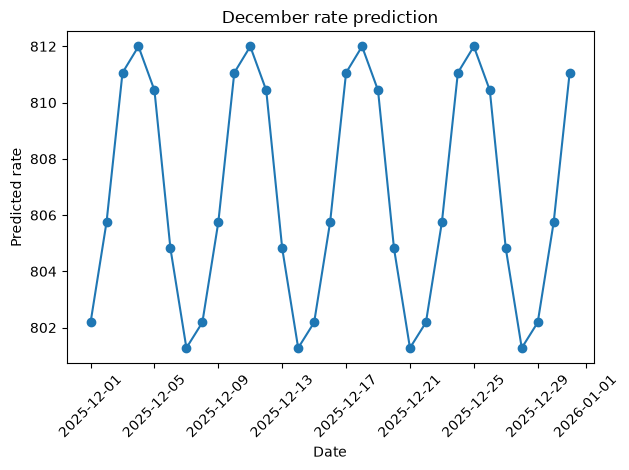

In [19]:
print("Validation rows:", len(predictions))
print("Missing validation predictions:", predictions["predicted_rate"].isna().sum())
print("December rows:", len(december_output))
print("Missing December predictions:", december_output["predicted_rate"].isna().sum())
print("Minimum validation rate:", predictions["predicted_rate"].min())
print("December rate range:", december_output["predicted_rate"].min(), december_output["predicted_rate"].max())

plt.plot(pd.to_datetime(december_output["date"]), december_output["predicted_rate"], marker="o")
plt.xlabel("Date")
plt.ylabel("Predicted rate")
plt.title("December rate prediction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()